## Data Downloading

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 97% 153M/157M [00:00<00:00, 1.60GB/s]
100% 157M/157M [00:00<00:00, 1.58GB/s]


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/brain-tumor-mri-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

## Importing Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from PIL import Image, ImageEnhance

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.preprocessing.image import load_img
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
from keras.applications.vgg16 import VGG16
from keras.optimizers import Adam
from keras.applications.vgg16 import preprocess_input
from sklearn.utils import shuffle

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Training',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 5600 files belonging to 4 classes.


In [ ]:
for labels in train_ds.class_names:
  print(labels)

glioma
meningioma
notumor
pituitary


In [ ]:
train_path = []
train_label = []

base_dir = '/content/Training'
class_names = train_ds.class_names # Get class names from the dataset

for i, class_name in enumerate(class_names):
  class_dir = os.path.join(base_dir, class_name)
  for image_name in os.listdir(class_dir):
    train_path.append(os.path.join(class_dir, image_name))
    train_label.append(i) # Assign integer label corresponding to class_name

train_label, train_path = shuffle(train_label, train_path)

In [ ]:
train_path

['/content/Training/glioma/Tr-gl_12.jpg',
 '/content/Training/pituitary/Tr-pi_259.jpg',
 '/content/Training/pituitary/Tr-pi_448.jpg',
 '/content/Training/pituitary/Tr-pi_974.jpg',
 '/content/Training/meningioma/Tr-me_514.jpg',
 '/content/Training/meningioma/Tr-me_93.jpg',
 '/content/Training/meningioma/Tr-me_1035.jpg',
 '/content/Training/meningioma/Tr-me_99.jpg',
 '/content/Training/meningioma/Tr-me_340.jpg',
 '/content/Training/meningioma/Tr-me_1282.jpg',
 '/content/Training/notumor/Tr-no_1343.jpg',
 '/content/Training/pituitary/Tr-pi_722.jpg',
 '/content/Training/glioma/Tr-gl_104.jpg',
 '/content/Training/meningioma/Tr-me_543.jpg',
 '/content/Training/pituitary/Tr-pi_1033.jpg',
 '/content/Training/notumor/Tr-no_809.jpg',
 '/content/Training/glioma/Tr-gl_1193.jpg',
 '/content/Training/glioma/Tr-gl_1028.jpg',
 '/content/Training/meningioma/Tr-me_787.jpg',
 '/content/Training/meningioma/Tr-me_264.jpg',
 '/content/Training/meningioma/Tr-me_201.jpg',
 '/content/Training/glioma/Tr-gl_1290

In [ ]:
train_label

[0,
 3,
 3,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 3,
 0,
 1,
 3,
 2,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 2,
 3,
 2,
 0,
 3,
 3,
 0,
 0,
 3,
 2,
 2,
 2,
 3,
 3,
 0,
 3,
 3,
 2,
 1,
 2,
 0,
 2,
 2,
 2,
 3,
 2,
 0,
 1,
 1,
 0,
 3,
 1,
 3,
 3,
 3,
 2,
 0,
 3,
 2,
 3,
 1,
 0,
 2,
 3,
 3,
 0,
 2,
 1,
 0,
 0,
 1,
 1,
 3,
 1,
 3,
 3,
 0,
 1,
 0,
 0,
 2,
 2,
 2,
 0,
 2,
 0,
 1,
 2,
 0,
 0,
 2,
 1,
 0,
 3,
 1,
 2,
 3,
 1,
 1,
 2,
 1,
 0,
 2,
 0,
 3,
 0,
 0,
 3,
 1,
 3,
 3,
 1,
 1,
 2,
 3,
 0,
 0,
 1,
 1,
 0,
 0,
 3,
 0,
 3,
 0,
 2,
 1,
 2,
 1,
 1,
 1,
 2,
 2,
 1,
 3,
 2,
 2,
 0,
 2,
 2,
 1,
 0,
 3,
 0,
 0,
 0,
 1,
 2,
 2,
 0,
 3,
 2,
 1,
 0,
 0,
 1,
 2,
 3,
 2,
 2,
 2,
 0,
 3,
 3,
 2,
 2,
 1,
 1,
 2,
 2,
 0,
 3,
 2,
 0,
 0,
 1,
 1,
 1,
 2,
 2,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 2,
 2,
 3,
 3,
 3,
 1,
 3,
 1,
 0,
 3,
 2,
 2,
 0,
 1,
 3,
 0,
 1,
 1,
 2,
 3,
 0,
 2,
 1,
 1,
 0,
 3,
 3,
 3,
 3,
 0,
 1,
 1,
 3,
 2,
 2,
 0,
 0,
 0,
 2,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 2,
 3,
 0,
 1,
 2,
 3,
 1,
 3,
 3,
 0,
 0,
 2,


In [ ]:
test_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Testing',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 1600 files belonging to 4 classes.


In [ ]:
test_path = []
test_label = []

base_test = '/content/Testing'
class_names = test_ds.class_names

for i, class_name in enumerate(class_names):
  class_dir = os.path.join(base_test, class_name)
  for image_name in os.listdir(class_dir):
    test_path.append(os.path.join(class_dir, image_name))
    test_label.append(i)

test_label, test_path = shuffle(test_label, test_path)

In [ ]:
test_path

['/content/Testing/meningioma/Te-aug-me_77.jpg',
 '/content/Testing/meningioma/Te-me_133.jpg',
 '/content/Testing/meningioma/Te-aug-me_58.jpg',
 '/content/Testing/meningioma/Te-aug-me_64.jpg',
 '/content/Testing/pituitary/Te-pi_306.jpg',
 '/content/Testing/glioma/Te-gl_262.jpg',
 '/content/Testing/meningioma/Te-aug-me_57.jpg',
 '/content/Testing/pituitary/Te-pi_256.jpg',
 '/content/Testing/glioma/Te-gl_250.jpg',
 '/content/Testing/notumor/Te-no_294.jpg',
 '/content/Testing/meningioma/Te-me_31.jpg',
 '/content/Testing/notumor/Te-no_277.jpg',
 '/content/Testing/notumor/Te-no_141.jpg',
 '/content/Testing/meningioma/Te-me_95.jpg',
 '/content/Testing/meningioma/Te-me_118.jpg',
 '/content/Testing/pituitary/Te-pi_203.jpg',
 '/content/Testing/glioma/Te-gl_72.jpg',
 '/content/Testing/meningioma/Te-me_194.jpg',
 '/content/Testing/glioma/Te-gl_284.jpg',
 '/content/Testing/notumor/Te-no_48.jpg',
 '/content/Testing/meningioma/Te-me_259.jpg',
 '/content/Testing/pituitary/Te-pi_67.jpg',
 '/content/Te

In [ ]:
test_label

[1,
 1,
 1,
 1,
 3,
 0,
 1,
 3,
 0,
 2,
 1,
 2,
 2,
 1,
 1,
 3,
 0,
 1,
 0,
 2,
 1,
 3,
 2,
 1,
 1,
 2,
 0,
 1,
 1,
 1,
 2,
 0,
 2,
 3,
 1,
 0,
 3,
 1,
 1,
 0,
 0,
 2,
 1,
 2,
 2,
 2,
 0,
 0,
 3,
 3,
 0,
 2,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 3,
 0,
 1,
 0,
 3,
 0,
 0,
 3,
 1,
 3,
 2,
 0,
 2,
 0,
 0,
 2,
 0,
 3,
 3,
 1,
 3,
 0,
 2,
 2,
 0,
 2,
 3,
 1,
 0,
 0,
 2,
 0,
 1,
 0,
 2,
 3,
 0,
 3,
 2,
 1,
 0,
 2,
 2,
 0,
 2,
 0,
 1,
 2,
 1,
 2,
 1,
 1,
 1,
 3,
 1,
 1,
 3,
 0,
 3,
 0,
 1,
 3,
 1,
 2,
 2,
 2,
 1,
 2,
 2,
 3,
 0,
 3,
 1,
 0,
 0,
 0,
 3,
 0,
 2,
 2,
 3,
 2,
 1,
 0,
 3,
 2,
 2,
 3,
 2,
 3,
 3,
 0,
 0,
 0,
 2,
 1,
 1,
 2,
 1,
 1,
 2,
 3,
 3,
 3,
 0,
 2,
 2,
 1,
 0,
 2,
 1,
 0,
 2,
 1,
 3,
 2,
 1,
 1,
 3,
 0,
 2,
 3,
 0,
 1,
 2,
 1,
 2,
 1,
 1,
 1,
 1,
 0,
 0,
 2,
 2,
 2,
 1,
 3,
 2,
 0,
 3,
 0,
 3,
 3,
 0,
 1,
 1,
 2,
 2,
 0,
 3,
 1,
 2,
 3,
 2,
 2,
 2,
 3,
 2,
 0,
 0,
 2,
 0,
 2,
 2,
 2,
 0,
 1,
 1,
 2,
 3,
 2,
 1,
 2,
 2,
 3,
 3,
 3,
 1,
 3,
 1,
 2,
 1,
 2,
 1,
 0,
 1,
 0,
 1,
 1,
 1,


## Data Visualization

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
random_ten = random.sample(range(len(train_path)), 10)

In [ ]:
random_ten

[3575, 3823, 1872, 1194, 5297, 5476, 2780, 1804, 3314, 4707]

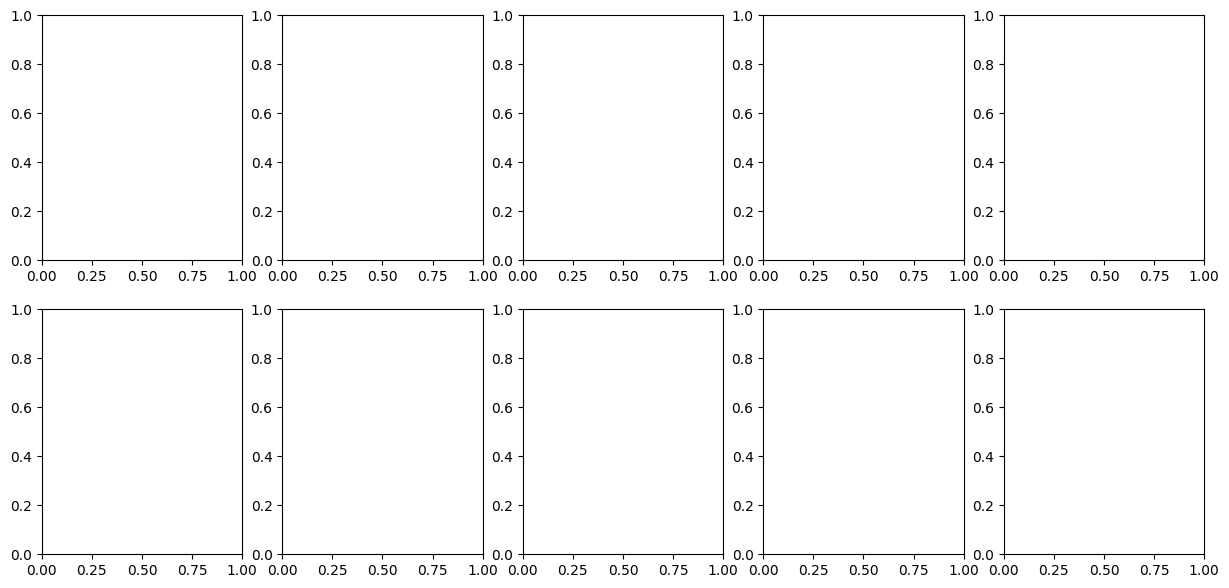

In [ ]:
fig, plt.axes = plt.subplots(2, 5, figsize=(15, 7))
axes = plt.axes.ravel()

In [ ]:
class_names = train_ds.class_names

for i,idx in enumerate(random_ten):
  img = cv2.imread(train_path[idx])
  img = Image.open(train_path[idx])
  img = img.resize((256, 256))
  axes[i].imshow(img)
  axes[i].axis("off")
  axes[i].set_title(f"Label - {class_names[train_label[idx]]}")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

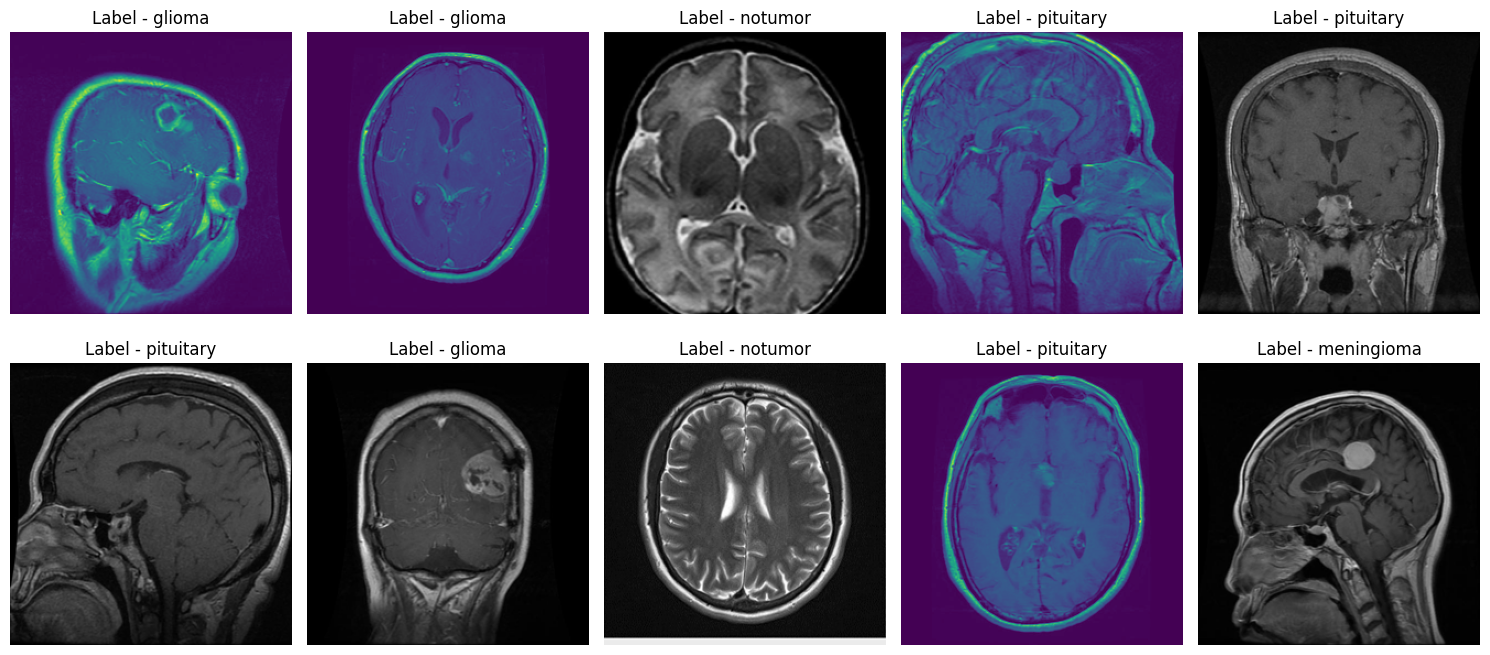

In [ ]:
random_ten_new = random.sample(range(len(train_path)), 10)

fig_new, plt_axes_new = plt.subplots(2, 5, figsize=(15, 7))
axes_new = plt_axes_new.ravel()

class_names = train_ds.class_names

for i, idx in enumerate(random_ten_new):
  img = Image.open(train_path[idx])
  img = img.resize((256, 256))
  axes_new[i].imshow(img)
  axes_new[i].axis("off")
  axes_new[i].set_title(f"Label - {class_names[train_label[idx]]}")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

label_counts = Counter(train_label)

class_names = train_ds.class_names

print("Counts of each label type in the training dataset:")
for label_id, count in label_counts.items():
  print(f"  {class_names[label_id]}: {count} images")

Counts of each label type in the training dataset:
  glioma: 1400 images
  pituitary: 1400 images
  meningioma: 1400 images
  notumor: 1400 images


In [ ]:
label_counts2 = Counter(test_label)

class_names2 = test_ds.class_names

print("Counts of each label type in the testing dataset:")
for label_id, count in label_counts2.items():
  print(f"  {class_names2[label_id]}: {count} images")

Counts of each label type in the testing dataset:
  meningioma: 400 images
  pituitary: 400 images
  glioma: 400 images
  notumor: 400 images


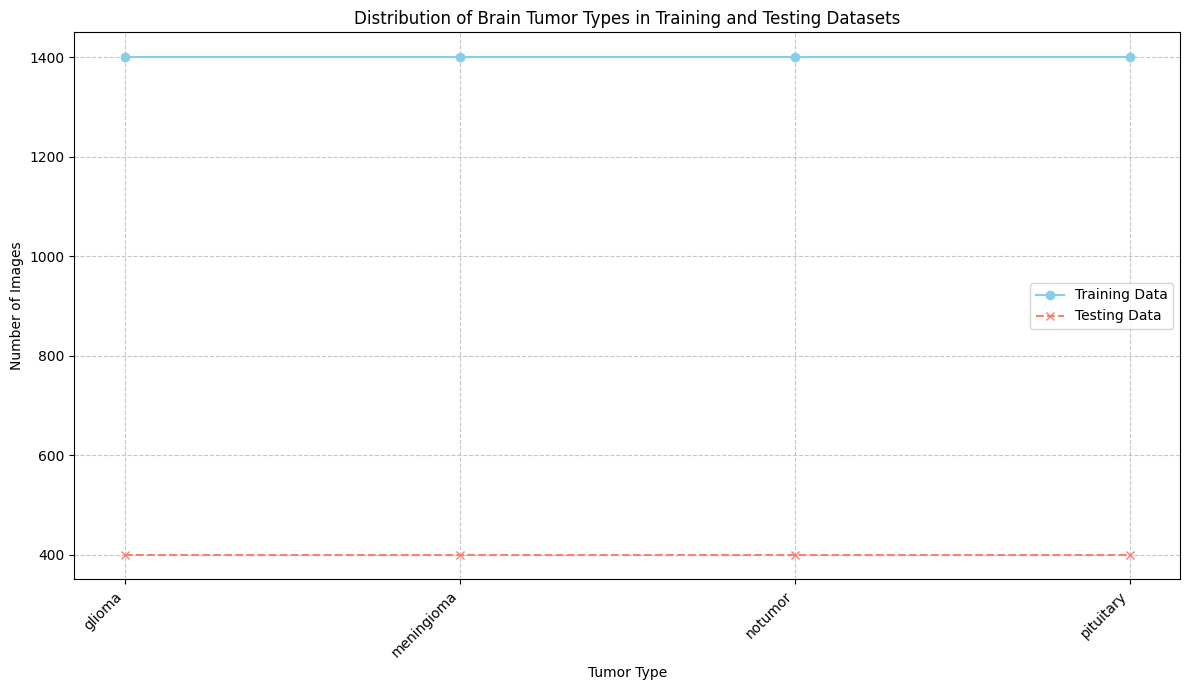

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data from training
train_labels_df = pd.DataFrame({
    'Class': [class_names[label_id] for label_id in label_counts.keys()],
    'Count': list(label_counts.values())
}).sort_values(by='Class').reset_index(drop=True)

# Data from testing set
test_labels_df = pd.DataFrame({
    'Class': [class_names2[label_id] for label_id in label_counts2.keys()],
    'Count': list(label_counts2.values())
}).sort_values(by='Class').reset_index(drop=True)

plt.figure(figsize=(12, 7))
plt.plot(train_labels_df['Class'], train_labels_df['Count'], marker='o', linestyle='-', color='skyblue', label='Training Data')
plt.plot(test_labels_df['Class'], test_labels_df['Count'], marker='x', linestyle='--', color='salmon', label='Testing Data')

plt.title('Distribution of Brain Tumor Types in Training and Testing Datasets')
plt.xlabel('Tumor Type')
plt.ylabel('Number of Images')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

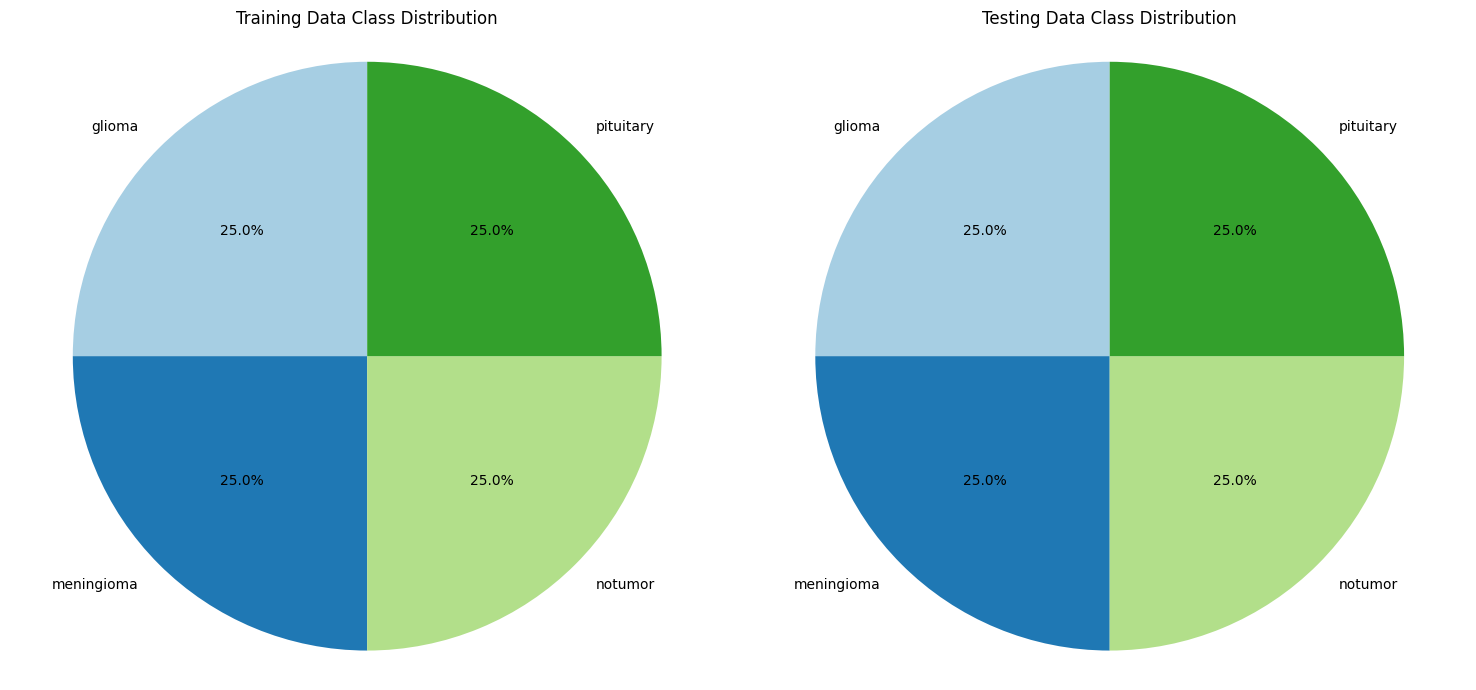

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Pie chart for Training Data
axes[0].pie(train_labels_df['Count'], labels=train_labels_df['Class'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
axes[0].set_title('Training Data Class Distribution')
axes[0].axis('equal')

# Pie chart for Testing Data
axes[1].pie(test_labels_df['Count'], labels=test_labels_df['Class'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
axes[1].set_title('Testing Data Class Distribution')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [ ]:
IMAGE_SIZE = 256

# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    class_names_list = train_ds.class_names
    encoded = [class_names_list.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = np.array(labels[i:i + batch_size]) # Convert labels to a NumPy array
            yield batch_images, batch_labels

## Model Training

In [ ]:
IMAGE_SIZE = 256
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layers in base_model.layers:
  layers.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

In [ ]:
from keras.layers import Input

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(train_ds.class_names), activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

batch_size = 36
steps = int(len(train_path) / batch_size)
epochs = 5

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,909,636 (72.13 MB)

 Trainable params: 11,274,372 (43.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
history = model.fit(datagen(train_path, train_label, batch_size=batch_size, epochs=epochs),epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 84s 357ms/step - loss: 0.6431 - sparse_categorical_accuracy: 0.7349
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 76s 356ms/step - loss: 0.2018 - sparse_categorical_accuracy: 0.9289
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 53s 344ms/step - loss: 0.1040 - sparse_categorical_accuracy: 0.9641
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 54s 347ms/step - loss: 0.0705 - sparse_categorical_accuracy: 0.9722
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 53s 344ms/step - loss: 0.0525 - sparse_categorical_accuracy: 0.9805


## Model Visualization

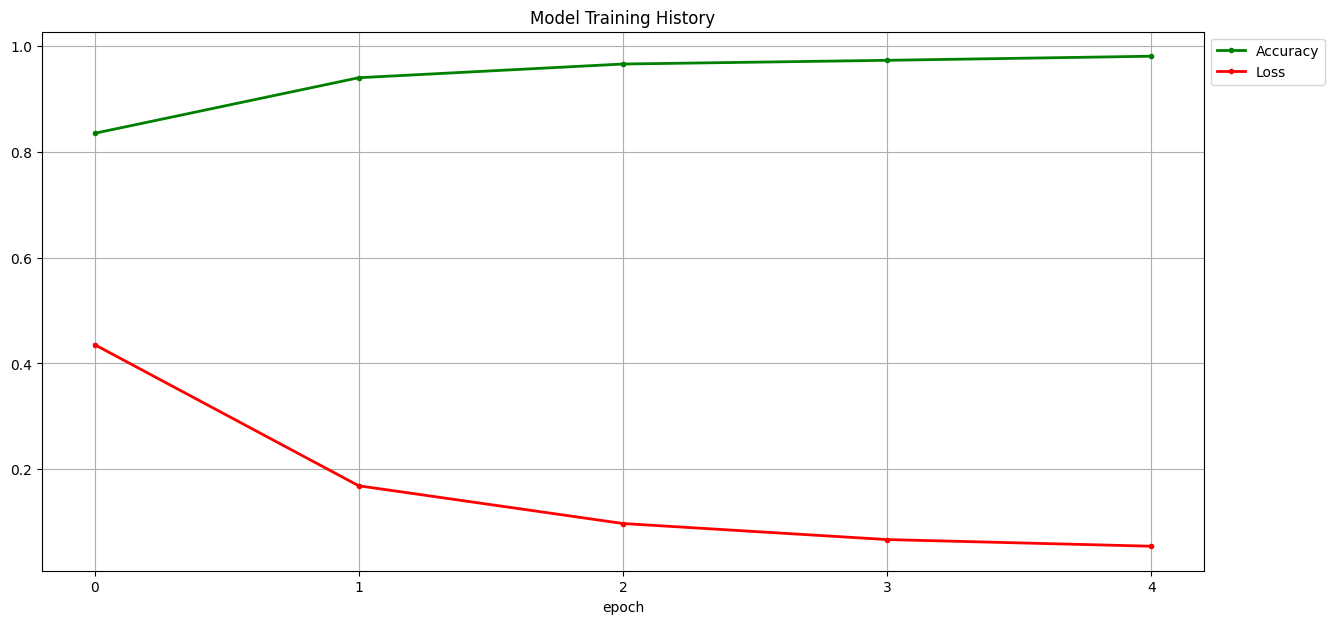

In [ ]:
plt.figure(figsize=(15, 7))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_path)
test_labels_encoded = test_label

test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 294ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       400
           1       0.85      0.98      0.91       400
           2       0.95      0.99      0.97       400
           3       0.98      0.98      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



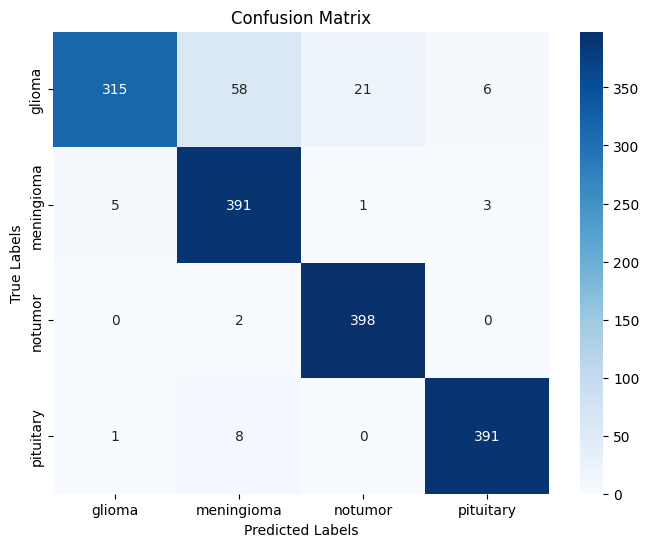

In [ ]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=train_ds.class_names, yticklabels=train_ds.class_names) # Corrected train_dir to train_ds.class_names
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

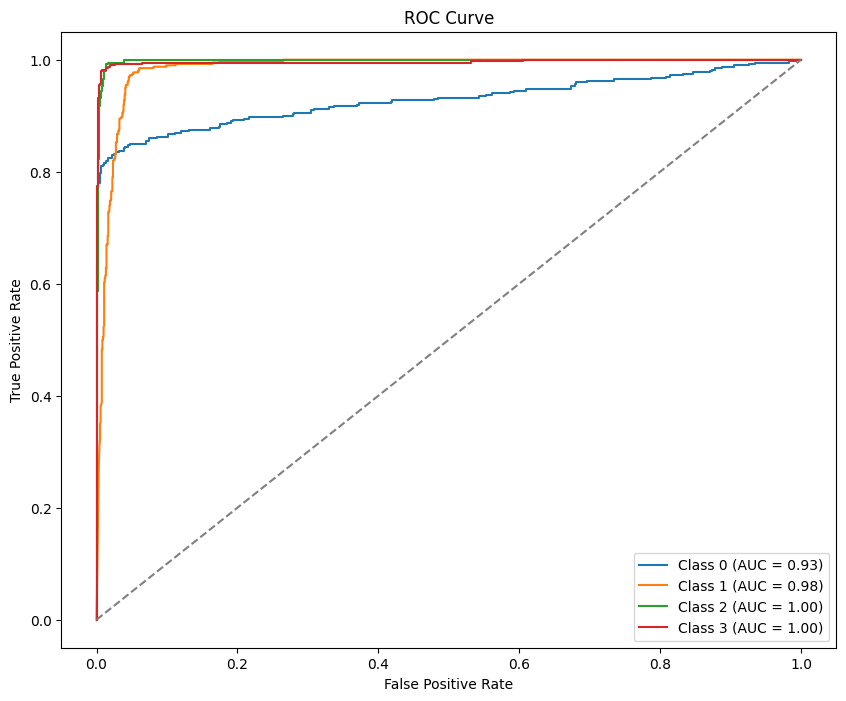

In [ ]:
# 4. ROC Curve and AUC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(train_ds.class_names))) # Corrected train_dir
test_predictions_bin = test_predictions

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(train_ds.class_names)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(train_ds.class_names)):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Model Saving

In [ ]:
model.save('model.h5')

In [ ]:
from keras.models import load_model
model = load_model("model.h5")

## System Configuration

In [ ]:
from keras.preprocessing.image import img_to_array
from keras.preprocessing.image import load_img

In [ ]:
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):

    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"

        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result}")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


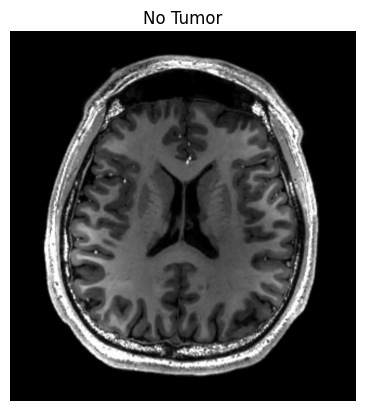

In [ ]:
img_path = '/content/MRI.jpg'
detect_and_display(img_path, model, image_size=IMAGE_SIZE) # Pass the correct IMAGE_SIZE

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


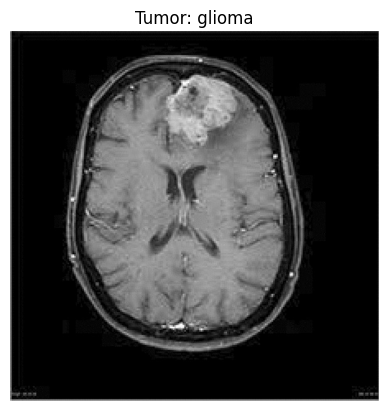

In [ ]:
img_path = '/content/Tumor.jpg'
detect_and_display(img_path, model, image_size=IMAGE_SIZE)

In [ ]:
from google.colab import files

files.download('model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>